<a href="https://colab.research.google.com/github/crd10lop/Modelos-udea-cristian-diez/blob/main/LAB%2002.02%20Nonparametric%20models%20-%20regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Laboratorio 2 - Parte 2. Modelos no paramétricos - regresión



In [ ]:
!wget -nc --no-cache -O init.py -q https://raw.githubusercontent.com/jdariasl/Intro_ML_2025/master/init.py
import init; init.init(force_download=False); init.get_weblink()

replicating local resources
replicating Labs resources


In [ ]:
from local.lib.rlxmoocapi import submit, session
import inspect
session.LoginSequence(endpoint=init.endpoint, course_id=init.course_id, lab_id="L02.02", varname="student");

logging in as cristian.diez@udea.edu.co... please wait

-------------
using course session introml::udea.vir.20261
success!! you are logged in
-------------


In [ ]:
#configuración del laboratorio
# Ejecuta esta celda!
from Labs.commons.utils.lab2 import *
_, x, y = part_2()
y = y.reshape(np.size(y), 1)

## Tarea 1: Exploración de datos

Para el problema de regresion usaremos la base de datos 'The California Housing Dataset', cuya descripción [pueden encontrarla aqui](https://inria.github.io/scikit-learn-mooc/python_scripts/datasets_california_housing.html). La información ya esta cargada dentro del notebook

In [ ]:
print("muestra de los 3 primeros renglones de x:\n", x[0:3, :])
print("muestra de los 3 primeros renglones de y:\n", y[0:3])
print ("Qué información nos brinda el resultado de esta instrucción?", x.shape[0])
print ("Qué información nos brinda el resultado de esta instrucción?", x.shape[1])
print ("Qué información nos brinda el resultado de esta instrucción?", len(np.unique(y)))

muestra de los 3 primeros renglones de x:
 [[ 8.32520000e+00  4.10000000e+01  6.98412698e+00  1.02380952e+00
   3.22000000e+02  2.55555556e+00  3.78800000e+01 -1.22230000e+02]
 [ 8.30140000e+00  2.10000000e+01  6.23813708e+00  9.71880492e-01
   2.40100000e+03  2.10984183e+00  3.78600000e+01 -1.22220000e+02]
 [ 7.25740000e+00  5.20000000e+01  8.28813559e+00  1.07344633e+00
   4.96000000e+02  2.80225989e+00  3.78500000e+01 -1.22240000e+02]]
muestra de los 3 primeros renglones de y:
 [[4.526]
 [3.585]
 [3.521]]
Qué información nos brinda el resultado de esta instrucción? 20640
Qué información nos brinda el resultado de esta instrucción? 8
Qué información nos brinda el resultado de esta instrucción? 3842


En los problemas de regresión, es muy útil explorar la distribución de la variable objetivo. Nuestro primer ejercicio consiste en:
1. visualizar un histograma de la variable. Vamos a realizar el histograma con 20 "cajones".
2. Usar el histograma para confirmar como estan distribuidos los datos

Pistas:
1. explorar la documentación de [plt.hist](https://matplotlib.org/3.3.1/api/_as_gen/matplotlib.pyplot.hist.html). Maneje los valores por defecto.

**NOTA**
Se quiere incentivar la lecutra de la documentación de las librerías, se debe hacer llamado explícito al parámetro a usar. Ejemplo si se necesita usar el parámetro `density`, se debe llamar como `plt.hist(density=True ....)`

In [ ]:
#ejercicio de código
def plot_hist_20(Y):
    """función que grafica el histograma de la variable 'Y'
        teniendo como valor fijo 20 en el parámetro que controla
        el número de "cajones"

        No retorna nada
    """
    import matplotlib.pyplot as plt
    plt.hist(Y, bins=20)

    return

**Registra tu solución en línea**

In [ ]:
student.submit_task(namespace=globals(), task_id='T1');

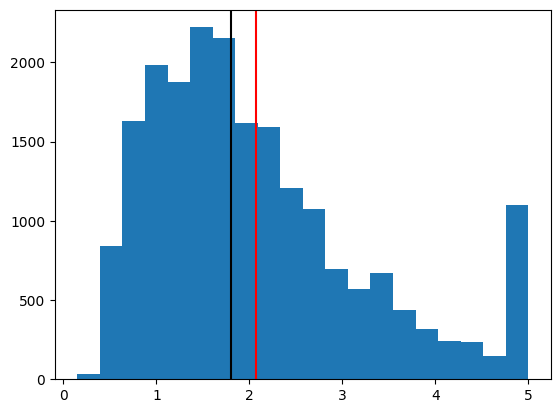

In [ ]:
# ver el histograma!
plot_hist_20(y)
# vamos realizar la representacion de la media y mediana
plt.axvline(y.mean(), c = 'r')
plt.axvline(np.median(y), c = 'k')
plt.show()

In [ ]:
#@title Pregunta Abierta
#@markdown Evaluando **solo** el histograma, ¿qué tan bien representa la media de y a todo el posible rango de valores de la variable objetivo?
respuesta = "No representa bien debido a que la distribución es asimétrica y presenta una cola larga a la derecha. La mediana sería una mejor medida." #@param {type:"string"}

## Tarea 2: K-Vecinos más cercanos para regresión.

Vamos a implementar ahora el modelo KNN para un problema de regresión.

Las mismas pistas de nuestro laboratorio anterior son de utilidad para implementar el algoritmo.

1. Para el cáculo de la distancia entre vectores existen varias opciones:
    1. usar la función la distancia entre matrices `scipy.spatial.distance.cdist`([Ejemplo](https://docs.scipy.org/doc/scipy/reference/generated/scipy.spatial.distance.cdist.html#scipy.spatial.distance.cdist))--esta puede ser usada directamente como `cdist(...)`. Entiende la salida de esta función. Al usarla, se logra un rendimiento superior.
    2. usar la función la distancia euclidiana `scipy.spatial.distance.euclidean`([Ejemplo](https://docs.scipy.org/doc/scipy/reference/generated/scipy.spatial.distance.euclidean.html))--pueder acceder a ella directamente como `euclidean`. Aca debe pensar en un algoritmo elemento a elemento, por lo tanto menos eficiente.
2. También serán de utilidad las funciones `np.sort` y `np.argsort`.
3. ¿Cuál es la única diferencia entre el knn para clasificación y regresión? en lugar de la moda, que metodo debemos usar?

In [ ]:
#ejercicio de código
def knn_regresion(k, X_train, Y_train, X_test):
    """ Función que implementa el modelo de K-Vecino mas cercanos
        para regresión
    """
    import numpy as np
    from scipy.spatial import distance

    # Cálculo eficiente de todas las distancias
    distancias = distance.cdist(X_test, X_train)

    # Ordenar por filas y extraer los índices de los k vecinos más cercanos
    indices_k_vecinos = np.argsort(distancias, axis=1)[:, :k]

    # Extraer los valores Y correspondientes (aplanando Y_train primero)
    # y calcular el promedio por fila (axis=1)
    Y_est = np.mean(Y_train.flatten()[indices_k_vecinos], axis=1)

    #Tener en cuenta que una implementación óptima no requiere ciclos for
    return (Y_est, distancias)

**Registra tu solución en línea**

In [ ]:
student.submit_task(namespace=globals(), task_id='T2');

## Tarea 3: Evaluar modelo K-Vecinos

Ahora vamos a probar nuestro algoritmo. Antes de ello, definos la función para calcular el error

In [ ]:
def MAPE(Y_est,Y):
    """Mean Absolute Percentage Error para los problemas de regresión
    Y_est: numpy array con los valores estimados
    Y: numpy array con las etiquetas verdaderas
    retorna: mape
    """
    N = np.size(Y)
    epsilon = 1e-10  # Pequeño valor para evitar división por cero
    mape = np.sum(abs((Y_est.reshape(N, 1) - Y.reshape(N, 1)) / (Y.reshape(N, 1) + epsilon))) / N
    return mape

Vamos a crear la función para experimentar.

En el ejercicio de código, se puede observar que usamos nuevamente la funciónes de la libreria **sklearn**:

1. [StandardScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html) para normalizar.

2. [train_test_split](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html). Para dividir el conjunto de datos. Entiende como estamos usando esta función y completa el codigo para realizar 5 particiones.

In [ ]:
#Ejercicio de código
def experimentar (ks, X, Y):
    """Función que realiza los experimentos con knn usando
       una estrategia de validacion entrenamiento y pruebas
    """
    import pandas as pd
    import numpy as np
    from sklearn.model_selection import train_test_split
    from sklearn.preprocessing import StandardScaler

    resultados = pd.DataFrame()
    idx = 0
    # iteramos sobre la lista de k's
    for k in ks:

        # iteramos para validar sobre las 5 particiones solicitadas
        for j in range(5):
            # dividimos usando la función
            Xtrain, Xtest, Ytrain, Ytest = train_test_split(X, Y, test_size=0.2, random_state=j)

            scaler = StandardScaler()
            scaler.fit(Xtrain)
            Xtrain= scaler.transform(Xtrain)
            Xtest = scaler.transform(Xtest)

            Yest, _ = knn_regresion(k, Xtrain, Ytrain, Xtest)
            errorTest = MAPE(Yest, Ytest)

            resultados.loc[idx,'k-vecinos'] = k
            resultados.loc[idx,'error de prueba'] = errorTest
            #asignamos la particion
            resultados.loc[idx, 'particion'] = j
            idx+=1

    return (resultados)

**Registra tu solución en línea**

In [ ]:
student.submit_task(namespace=globals(), task_id='T3');

Ahora ejecuta los experimentos con k = 2,3,4

In [ ]:
resultados = experimentar ([2,3,4], x, y)
resultados

,k-vecinos,error de prueba,particion
0,2.0,0.255543,0.0
1,2.0,0.262266,1.0
2,2.0,0.257779,2.0
3,2.0,0.253148,3.0
4,2.0,0.256562,4.0
5,3.0,0.243795,0.0
6,3.0,0.247859,1.0
7,3.0,0.247124,2.0
8,3.0,0.245474,3.0
9,3.0,0.245114,4.0


## Tarea 4: Ventana de Parzen

Ahora, igualmente, vamos aplicar ventana de parzen para resolver el problema de regresión.

$$f({\bf{x}}^*) = \frac{1}{N h^d} \sum_{i=1}^{N} K(u_i), \;\; u_i = \frac{d({\bf{x}}^*,{\bf{x}}_i)}{h}$$

En la siguiente celda se define la función para un $K(u_i)$ gaussiano y se realiza la sugerencia para estimar el termino $ \sum_{i=1}^{N} K(u_i)$, siendo $\;\; u_i = \frac{d({\bf{x}}^*,{\bf{x}}_i)}{h}$.

Observa y entiende esta última función y sus argumentos. Recordando que para regresión, debemos usar la relación de **Nadaraya_Watson**.

$$y^* = \frac{\sum_{i=1}^N K(u_i)y_i}{\sum_{i=1}^N K(u_i)} $$



In [ ]:
def kernel_gaussiano(x):
    return (np.exp((-0.5)*x**2))

def ParzenWindow(x,Data,h,Datay=None):
    from scipy.spatial.distance import euclidean
    """"ventana de parzen
    x: vector con representando una sola muestra
    Data: vector de muestras de entrenamiento
    h: ancho de la ventana de kernel
    Datay: vector con los valores de salida (y), Si no se pasa como argumento,
        se calcula un ventana de parzen sin multiplicar los valores de este vector.
    retorna: el valor de ventana de parzen para una muestra
    """
    h = h
    Ns = Data.shape[0]
    suma = 0
    for k in range(Ns):
        u = euclidean(x,Data[k,:])
        if Datay is None:
            suma += kernel_gaussiano(u/h)
        else:
            suma += kernel_gaussiano(u/h)*Datay[k]
    return suma


Usando las anteriores funciones, completa el código.

In [ ]:
# Ejercicio de código
def Nadaraya_Watson(h, X_train, Y_train, X_test):
    """ Función que implementa metodo de ventana de parzen para
        regresión aplicando corrección de división por cero.
    """
    import numpy as np
    from scipy.spatial import distance

    # 1. Matriz de distancias euclidianas al cuadrado
    dist_sq = distance.cdist(X_test, X_train, 'sqeuclidean')

    # 2. Matriz del Kernel Gaussiano
    K = np.exp(-0.5 * dist_sq / (h**2))

    # 3. Calculamos el numerador (Suma ponderada de las etiquetas)
    numerador = np.dot(K, Y_train.flatten())

    # 4. Calculamos el denominador (Suma de los pesos del kernel)
    denominador = np.sum(K, axis=1)

    # 5.
    Yest = numerador / (denominador + 1e-10)

    return Yest

**Registra tu solución en línea**

In [ ]:
student.submit_task(namespace=globals(), task_id='T4');

## Tarea 5: Experimentos con Parzen
En el ejercicio de código, se puede observar que usamos nuevamente la funciónes de la libreria **sklearn**:

1. [StandardScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html) para normalizar.
2. Y se debe usar la función [KFold](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.KFold.html?highlight=kfold#sklearn.model_selection.KFold) para realizar la validación. Tener en cuenta la documentación para poder completar el código de manera correcta y usar 3 particiones.

In [ ]:
def experimentarParzen (hs, X, Y):
    """Función que realiza los experimentos con knn usando
       una estrategia de validacion entrenamiento y pruebas
    """
    import pandas as pd
    import numpy as np
    from sklearn.model_selection import KFold
    from sklearn.preprocessing import StandardScaler

    # se usa la función para implementar la estrategia de validación.
    # asgine el valor acorde (3 particiones)
    kfolds = KFold(n_splits=3, shuffle=True, random_state=0)
    resultados = pd.DataFrame()
    idx = 0

    # iteramos sobre los valores de hs
    for h in hs:

        #contador para cada particion
        particion = 0
        # asigne el valor al parametro X
        for train, test in kfolds.split(X = X):

            # como usar train y test
            Xtrain = X[train, :]
            Ytrain = Y[train]
            Xtest = X[test, :]
            Ytest = Y[test]

            #normalizamos los datos
            scaler = StandardScaler()
            scaler.fit(Xtrain)
            Xtrain = scaler.transform(Xtrain)
            Xtest = scaler.transform(Xtest)

            Yest = Nadaraya_Watson(h, Xtrain, Ytrain, Xtest)
            errorTest = MAPE(Yest, Ytest)

            resultados.loc[idx,'ancho de ventana'] = h
            resultados.loc[idx,'error de prueba'] = errorTest
            resultados.loc[idx,'particion'] = particion
            idx+=1
            particion+=1

    return (resultados)

**Registra tu solución en línea**

In [ ]:
student.submit_task(namespace=globals(), task_id='T5');

In [ ]:
# ejecute para ver los experimentos
hs = [1,1.5 ,2.5, 5, 10]
experimentos_parzen = experimentarParzen(hs, x,y)
experimentos_parzen

,ancho de ventana,error de prueba,particion
0,1.0,0.443604,0.0
1,1.0,0.442343,1.0
2,1.0,0.433184,2.0
3,1.5,0.505230,0.0
4,1.5,0.504847,1.0
5,1.5,0.492287,2.0
6,2.5,0.565386,0.0
7,2.5,0.566215,1.0
8,2.5,0.551298,2.0
9,5.0,0.607567,0.0


In [ ]:
# para ver el mejor modelo
# vamos a calcular el valor medio
# Y order acorde y observamos
# el primer valor
(experimentos_parzen
 .groupby(['ancho de ventana'], as_index=False)['error en conjunto de prueba'].mean()
 .sort_values(by='error en conjunto de prueba', ascending = True)
 .head(1))

KeyError: 'Column not found: error en conjunto de prueba'

In [ ]:
#@title Pregunta Abierta
#@markdown ¿En qué consiste el metodo Silverman bandwidth? Explique brevemente y en sus palabras
respuesta = "Es una regla matemática que permite calcular de forma automática el ancho de ventana (h) óptimo usando la desviación estándar y el tamaño muestral, evitando métodos iterativos de ensayo y error." #@param {type:"string"}